# Systematic Trading in Commodity Markets

### Momentum, Trend Following and Mean Reversion Across Gold, Oil, Natural gas and Copper

This project asks a simple question:

> **Can simple systematic trading rules change the risk and return of commodity exposures in a useful way, and do those results survive trading costs, different time period and reasonable changes in the strategy settings?**

We test 4 markets:

 - Buy & Hold
 - Momentum
 - Trend Following
 - Mean Reversion

The goal is not to find a magic super trading rule.

It is to test simple ideas honestly and understand when they work, when they fail, and why.

In [86]:
# the baseline imports we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [87]:
# the 4 commodity markets we are studying
markets = ["GLD", "USO", "UNG", "CPER"]

# period of research
start = "2012-01-03"
end = "2026-09-01"

# Every wealth curve begins at the same simple index value
startingWealth = 10000

## 1. Data 

Before testing any trading idea, we need one clean price history for every market. We use daily adjusted closing prices so each strategy sees same type of data over same time. Simply it is just boring: download data, check it, make sure nothings broken

### What are we actually trading?

GLD, USO, UNG, CPER are exchanged-traded ways of gaining exposure to commodity markets.

They are useful giving us consistent, tradable daily price histories, but are proxies rather than the actual physical commodities themselves.

Distinction matters.

In [88]:
# downloading all 4 markets in one go
raw = yf.download(
    markets,
    start=start,
    end=end,
    interval="1d",
    auto_adjust=False,
    progress=False
)

prices = raw["Adj Close"][markets].copy()

prices.head()

Ticker,GLD,USO,UNG,CPER
Date,,,,
2012-01-03,155.919998,317.519989,414.079987,25.16
2012-01-04,156.710007,318.160004,430.079987,24.40
2012-01-05,157.779999,313.359985,410.880005,24.35
2012-01-06,157.199997,313.760010,424.959991,24.42
2012-01-09,156.500000,312.640015,417.920013,24.42


In [89]:
# quick check before trsuting data
print("First date:", prices.index.min().date())
print("Last date: ", prices.index.max().date())
print("Trading days:", len(prices))

print("\nMissing values:")
print(prices.isna().sum())

First date: 2012-01-03
Last date:  2026-08-31
Trading days: 3686

Missing values:
Ticker
GLD     0
USO     0
UNG     0
CPER    0
dtype: int64


### Comparing 4 markets

The 4 instruments have very different price levels, so plotting raw data by itself would be misleading.

Instead what we could do is rebase the series to 100 on first day:

$$
I_t = 100 \times \frac{P_t}{P_0}
$$

where $P_0$ is the starting price.

Returns do not change, it simply puts every market on the same scale so we can compare their values through time.

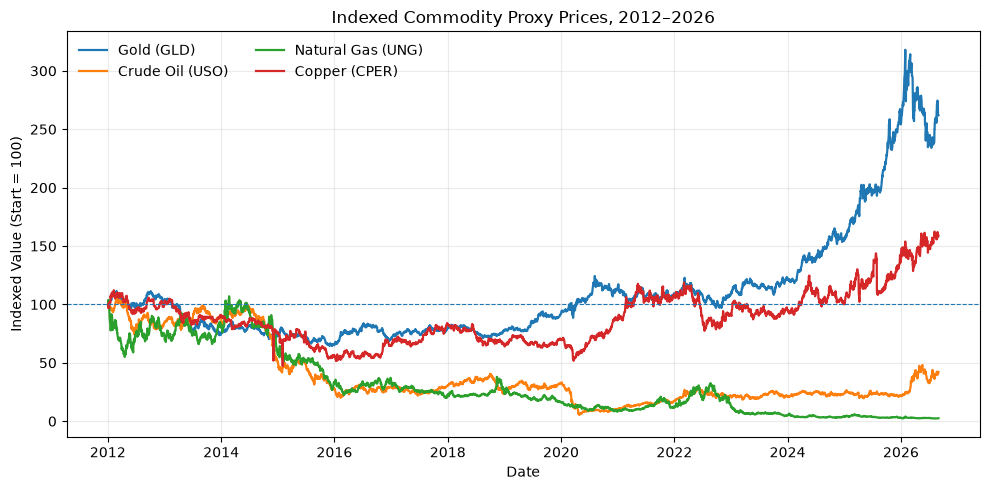

In [90]:
#put every market on same starting scale

indexed = prices / prices.iloc[0] * 100

names = {
    "GLD": "Gold (GLD)",
    "USO": "Crude Oil (USO)",
    "UNG": "Natural Gas (UNG)",
    "CPER": "Copper (CPER)"
}

fig, ax = plt.subplots(figsize=(10, 5))

for market in markets:
    ax.plot(
        indexed.index,
        indexed[market],
        label=names[market],
        linewidth=1.6
    )

ax.axhline(100, linewidth=0.8, linestyle="--")

ax.set_title("Indexed Commodity Proxy Prices, 2012–2026")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Value (Start = 100)")

ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    "figures/figure_01_market_paths.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Daily Returns

Prices show where each market is.

Trading strategies care about: how the price changes from one day to the next.

We need to calculate daily return:

$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

where:

- $P_t$ = today's adjusted closing price
- $P_{t-1}$ = the previous trading day's price

Return of 0.01 means market rose by 1% that day.

These daily returns will be the building blocks for every strategy in this project.

In [91]:
# calc daily percentage change for each market

returns = prices.pct_change().dropna()

returns.head()

Ticker,GLD,USO,UNG,CPER
Date,,,,
2012-01-04,0.005067,0.002016,0.038640,-0.030207
2012-01-05,0.006828,-0.015087,-0.044643,-0.002049
2012-01-06,-0.003676,0.001277,0.034268,0.002875
2012-01-09,-0.004453,-0.003570,-0.016566,0.000000
2012-01-10,0.013674,0.006653,-0.030628,0.000000


## 2. Strategy Rules

We test 3 simple trading ideas against Buy & Hold.

The rules are fixed here before looking at their performance.

### Momentum

Momentum asks whether the market has risen over the previous 126 trading days:

$$
M_t = \frac{P_t}{P_{t-126}} - 1
$$

- $M_t > 0$ → invested
- $M_t \leq 0$ → cash

### Trend Following

Trend following compares a faster 50-day moving average with a slower 200-day moving average:

$$
MA_n(t) = \frac{1}{n}\sum_{i=0}^{n-1}P_{t-i}
$$

- $MA_{50} > MA_{200}$ → invested
- otherwise → cash

### Mean reversion

Mean reversion measures how far price sits from its recent 20-day average:

$$
z_t = \frac{P_t-\mu_t}{\sigma_t}
$$

- enter when $z_t \leq -1.5$
- remain invested while price recovers
- exit when $z_t \geq 0$

All 3 strategies are **long or cash only**. No short selling or leverage used.

In [96]:
# The rules of the game,  fixed before we test performance
momentumDays = 126

fastDays = 50
slowDays = 200

meanDays = 20
entryZ = -1.5
exitZ = 0

In [97]:
# Turn a price history into the four positions we want to test
def buildPositions(price):

    # Buy & Hold is always invested
    buyHold = pd.Series(1.0, index=price.index)

    # Momentum
    momentum = price.pct_change(momentumDays)

    momPos = pd.Series(np.nan, index=price.index)
    ready = momentum.notna()
    momPos.loc[ready] = (momentum.loc[ready] > 0).astype(float)

    # Trend Following
    fastMA = price.rolling(fastDays).mean()
    slowMA = price.rolling(slowDays).mean()

    trendPos = pd.Series(np.nan, index=price.index)
    ready = slowMA.notna()
    trendPos.loc[ready] = (fastMA.loc[ready] > slowMA.loc[ready]).astype(float)

    # Mean Reversion
    average = price.rolling(meanDays).mean()
    spread = price.rolling(meanDays).std()
    zScore = (price - average) / spread

    meanPos = pd.Series(np.nan, index=price.index)
    holding = 0

    for date in zScore.dropna().index:

        if zScore.loc[date] <= entryZ:
            holding = 1

        elif zScore.loc[date] >= exitZ:
            holding = 0

        meanPos.loc[date] = holding

    return pd.DataFrame({
        "Buy & Hold": buyHold,
        "Momentum": momPos,
        "Trend": trendPos,
        "Mean Reversion": meanPos
    })

In [98]:
# tiny check

goldPositions = buildPositions(prices["GLD"])

goldPositions.tail()

,Buy & Hold,Momentum,Trend,Mean Reversion
Date,,,,
2026-08-25,1.0,0.0,0.0,0.0
2026-08-26,1.0,0.0,0.0,0.0
2026-08-27,1.0,0.0,0.0,0.0
2026-08-28,1.0,0.0,0.0,0.0
2026-08-31,1.0,0.0,0.0,0.0


## 3. Backtest engine

The strategy rules tell us whther we want to be invested or in cash.

The backtest turns those decisions into returns.

Key timing rule:

$$
R^{strategy}_t
=
Position_{t-1} \times R_t
$$

Today's position is based on information available at yesterdays close.

This one day shift is important -> stops backtest from using todays closign price before todays return has actually happened.

For fair compariosn: all 4 approaches begin once every strategy has enough historical data to make a decsion.

In [ ]:
# time to turn our trading decisions into timed returns
def runBacktest(price):

    positions = buildPositions(price)
    marketReturn = price.pct_change()

    # Yesterday's decision controls today's return
    held = positions.shift(1) # waht each appraoch was actually holding that day

    strategyReturns = held.mul(marketReturn, axis=0) # what each approach earned each day

    # Start only once every strategy is ready
    ready = held.notna().all(axis=1) & marketReturn.notna()
    firstDay = ready[ready].index[0]

    strategyReturns = strategyReturns.loc[firstDay:].copy()
    held = held.loc[firstDay:].copy()

    return strategyReturns, held

In [100]:
# run the same experiement on every market
backtests = {}
heldPositions = {}

for market in markets:
    backtests[market], heldPositions[market] = runBacktest(prices[market])

print("Backtests ready:", list(backtests.keys()))

Backtests ready: ['GLD', 'USO', 'UNG', 'CPER']


In [101]:
#quick timing test
for market in markets:
    print(
        market,
        "| start:", backtests[market].index[0].date(),
        "| days:", len(backtests[market]),
        "| missing:", backtests[market].isna().sum().sum()
    )

GLD | start: 2012-10-17 | days: 3486 | missing: 0
USO | start: 2012-10-17 | days: 3486 | missing: 0
UNG | start: 2012-10-17 | days: 3486 | missing: 0
CPER | start: 2012-10-17 | days: 3486 | missing: 0


## 4. Performance scorecared

Every strategy is judged using the same set of return and risk measures.

### Total return

Overall percent change in wealth:

$$
\text{Total Return}
=
\frac{W_T}{W_0}-1
$$

### Compound Annual gorwth rate

The constant annual growth rate that would produce the same final wealth:

$$
\text{CAGR}
=
\left(
\frac{W_T}{W_0}
\right)^{1/T}
-1
$$

### Annualised Volatility

How much daily returns fluctuate, scaled to one trading year:

$$
\sigma_{\text{annual}}
=
\sigma_{\text{daily}}\sqrt{252}
$$

### Sharpe ratio

Return relative to overall return variation:

$$
\text{Sharpe}
=
\frac{\overline{R}}
{\sigma_R}
\sqrt{252}
$$

### Sortino ratio

Similar to Sharpe BUT only downside variation is treated harmful:

$$
\text{Sortino}
=
\frac{\overline{R}}
{\sigma_{\text{downside}}}
\sqrt{252}
$$

### Maximum drawdown

The largest fall from previous portfolio high:

$$
\text{Drawdown}_t
=
\frac{W_t}{\text{Peak}_t}-1
$$

Sharpe and Sortino use risk-free return of 0 in this study just fyi.


In [102]:
# 1 scorecard function
# for every market sand strategy

daysPerYear = 252

def scorecard(r):

    # Growth of £1 
    wealth = (1 + r).cumprod()

    years = (r.index[-1] - r.index[0]).days / 365.25

    total = wealth.iloc[-1] - 1
    cagr = wealth.iloc[-1] ** (1 / years) - 1

    vol = r.std() * np.sqrt(daysPerYear)
    sharpe = r.mean() / r.std() * np.sqrt(daysPerYear)

    downside = np.sqrt(np.mean(np.minimum(r, 0) ** 2))
    sortino = r.mean() / downside * np.sqrt(daysPerYear)

    # Treat the original £1 as the first portfolio high
    peak = wealth.cummax().clip(lower=1)
    drawdown = wealth / peak - 1
    worst = drawdown.min()

    return {
        "Total Return": total,
        "CAGR": cagr,
        "Annual Volatility": vol,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Maximum Drawdown": worst
    }

## quick little note that this starts at 1 not 10000 but you cna just multiply it

In [103]:
#sanity check

scorecard(backtests["GLD"]["Buy & Hold"])

{'Total Return': np.float64(1.4106954187336194),
 'CAGR': np.float64(0.06549597673424379),
 'Annual Volatility': np.float64(0.16508193571395693),
 'Sharpe Ratio': np.float64(0.46822105995888497),
 'Sortino Ratio': np.float64(0.6543046042988238),
 'Maximum Drawdown': np.float64(-0.40746418466868317)}

## 5. Baseline Results

We can finally now run the same experiemnet across all 4 of the commodity markets.

These are our baseline results:

- the strategy rules are exactly those defined in Section 2
- no transaction costs are included yet
- every approach begins on the same date
- every market is measured using the same scorecard



In [ ]:
# lets build that master table

rows = []

for market in markets:
    for strategy in backtests[market].columns:

        scores = scorecard(backtests[market][strategy])

        rows.append({
            "Market": market,
            "Strategy": strategy,
            **scores
        })

baseline = pd.DataFrame(rows).set_index(["Market", "Strategy"])

baseline

# table looks insane

Total Return      CAGR  Annual Volatility  \
Market Strategy                                                    
GLD    Buy & Hold          1.410695  0.065496           0.165082   
       Momentum            1.457724  0.066981           0.131646   
       Trend               0.867784  0.046073           0.131004   
       Mean Reversion      0.155428  0.010471           0.091438   
USO    Buy & Hold         -0.510328 -0.050177           0.375893   
       Momentum            0.623763  0.035567           0.238244   
       Trend              -0.050794 -0.003751           0.235891   
       Mean Reversion     -0.596975 -0.063419           0.259687   
UNG    Buy & Hold         -0.970327 -0.224003           0.505120   
       Momentum           -0.747628 -0.094500           0.325621   
       Trend              -0.338776 -0.029384           0.299774   
       Mean Reversion     -0.420521 -0.038575           0.300180   
CPER   Buy & Hold          0.524390  0.030863           0.321722   
       Momentum            0.619296  0.035362           0.174875   
       Trend               0.629376  0.035825           0.174733   
       Mean Reversion      0.966533  0.049966           0.254173   

                       Sharpe Ratio  Sortino Ratio  Maximum Drawdown  
Market Strategy                                                       
GLD    Buy & Hold          0.468221       0.654305         -0.407464  
       Momentum            0.559941       0.784403         -0.259789  
       Trend               0.410549       0.570939         -0.264713  
       Mean Reversion      0.160172       0.218638         -0.214599  
USO    Buy & Hold          0.053612       0.073046         -0.945884  
       Momentum            0.266518       0.375369         -0.562037  
       Trend               0.102303       0.142702         -0.579186  
       Mean Reversion     -0.119013      -0.157169         -0.876119  
UNG    Buy & Hold         -0.249924      -0.352301         -0.978264  
       Momentum           -0.140931      -0.196086         -0.761934  
       Trend               0.050395       0.072423         -0.496729  
       Mean Reversion      0.018026       0.026182         -0.712986  
CPER   Buy & Hold          0.249931       0.389406         -0.548901  
       Momentum            0.287981       0.392602         -0.341513  
       Trend               0.290511       0.400145         -0.282236  
       Mean Reversion      0.311410       0.534222         -0.392161

In [ ]:
# gonna make a cleaner version for the noteebook:

baselineView = baseline.copy()

percentCols = [
    "Total Return",
    "CAGR",
    "Annual Volatility",
    "Maximum Drawdown"
]

for column in percentCols:
    baselineView[column] = baselineView[column].map(lambda x: f"{x:.1%}")

baselineView["Sharpe Ratio"] = baselineView["Sharpe Ratio"].map(lambda x: f"{x:.2f}")
baselineView["Sortino Ratio"] = baselineView["Sortino Ratio"].map(lambda x: f"{x:.2f}")

baselineView # this is the 'human=friendly' view looks even cooler


Total Return    CAGR Annual Volatility Sharpe Ratio  \
Market Strategy                                                             
GLD    Buy & Hold           141.1%    6.5%             16.5%         0.47   
       Momentum             145.8%    6.7%             13.2%         0.56   
       Trend                 86.8%    4.6%             13.1%         0.41   
       Mean Reversion        15.5%    1.0%              9.1%         0.16   
USO    Buy & Hold           -51.0%   -5.0%             37.6%         0.05   
       Momentum              62.4%    3.6%             23.8%         0.27   
       Trend                 -5.1%   -0.4%             23.6%         0.10   
       Mean Reversion       -59.7%   -6.3%             26.0%        -0.12   
UNG    Buy & Hold           -97.0%  -22.4%             50.5%        -0.25   
       Momentum             -74.8%   -9.5%             32.6%        -0.14   
       Trend                -33.9%   -2.9%             30.0%         0.05   
       Mean Reversion       -42.1%   -3.9%             30.0%         0.02   
CPER   Buy & Hold            52.4%    3.1%             32.2%         0.25   
       Momentum              61.9%    3.5%             17.5%         0.29   
       Trend                 62.9%    3.6%             17.5%         0.29   
       Mean Reversion        96.7%    5.0%             25.4%         0.31   

                      Sortino Ratio Maximum Drawdown  
Market Strategy                                       
GLD    Buy & Hold              0.65           -40.7%  
       Momentum                0.78           -26.0%  
       Trend                   0.57           -26.5%  
       Mean Reversion          0.22           -21.5%  
USO    Buy & Hold              0.07           -94.6%  
       Momentum                0.38           -56.2%  
       Trend                   0.14           -57.9%  
       Mean Reversion         -0.16           -87.6%  
UNG    Buy & Hold             -0.35           -97.8%  
       Momentum               -0.20           -76.2%  
       Trend                   0.07           -49.7%  
       Mean Reversion          0.03           -71.3%  
CPER   Buy & Hold              0.39           -54.9%  
       Momentum                0.39           -34.2%  
       Trend                   0.40           -28.2%  
       Mean Reversion          0.53           -39.2%

### Strategy Wealth Paths

TO make the strategy paths directly comparable, each one begins with index of 100 (just imagine £100).

$$
W_t = 100\prod_{i=1}^{t}(1+R_i)
$$

Shows how each approach would have grown or fallen through time with NO CURRENCY.

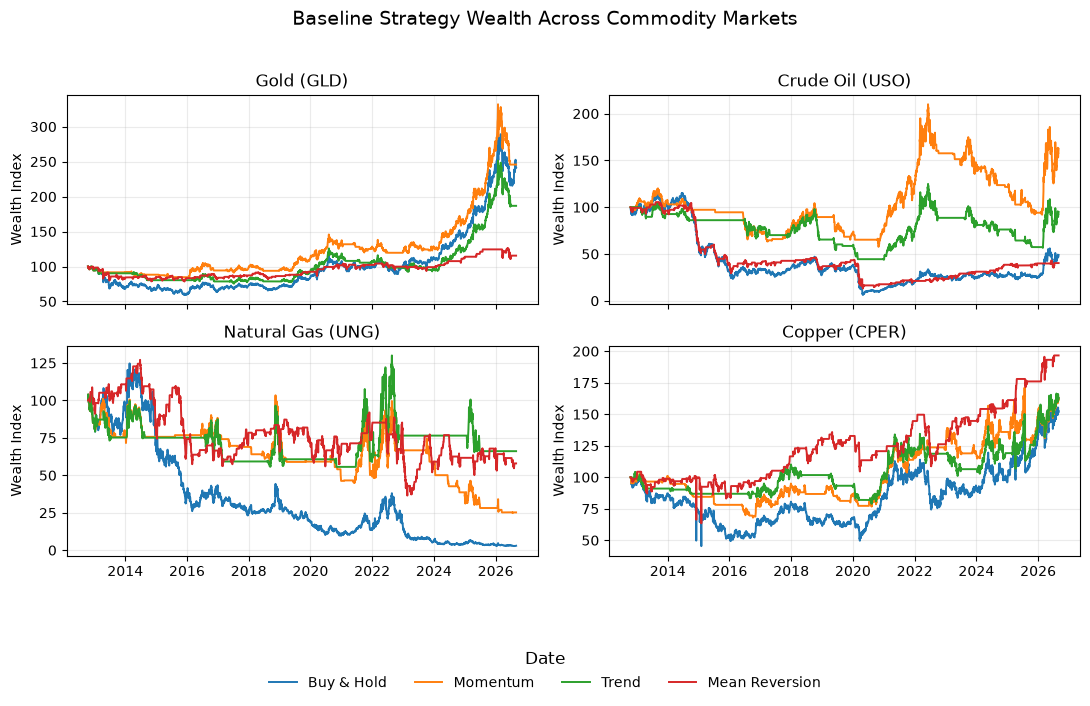

In [107]:
# figure 2 has so much aura 
#go back and check the date position on teh graph

# figure 2 showing how each stregy has moved through time - time series
fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 7),
    sharex=True
)

axes = axes.flatten()

marketNames = {
    "GLD": "Gold (GLD)",
    "USO": "Crude Oil (USO)",
    "UNG": "Natural Gas (UNG)",
    "CPER": "Copper (CPER)"
}

for ax, market in zip(axes, markets):

    wealth = (1 + backtests[market]).cumprod() * 100

    for strategy in wealth.columns:
        ax.plot(
            wealth.index,
            wealth[strategy],
            label=strategy,
            linewidth=1.4
        )

    ax.set_title(marketNames[market])
    ax.set_ylabel("Wealth Index")
    ax.grid(alpha=0.25)

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01)
)

fig.suptitle(
    "Baseline Strategy Wealth Across Commodity Markets",
    fontsize=14
)

fig.supxlabel("Date", y=0.04)

fig.tight_layout(rect=[0, 0.10, 1, 0.96])

fig.savefig(
    "figures/figure_02_baseline_wealth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Risk-Adjusted performance

Total return alone is just not going to tell use how difficult the journey was.

Sharpe ratio compares avergae retun witht eh amount of variation in returns, allowing those same strategies to be compared across different commodity markets.

Higher Sharpe Ratio = more return relative to the amount of risk taken.


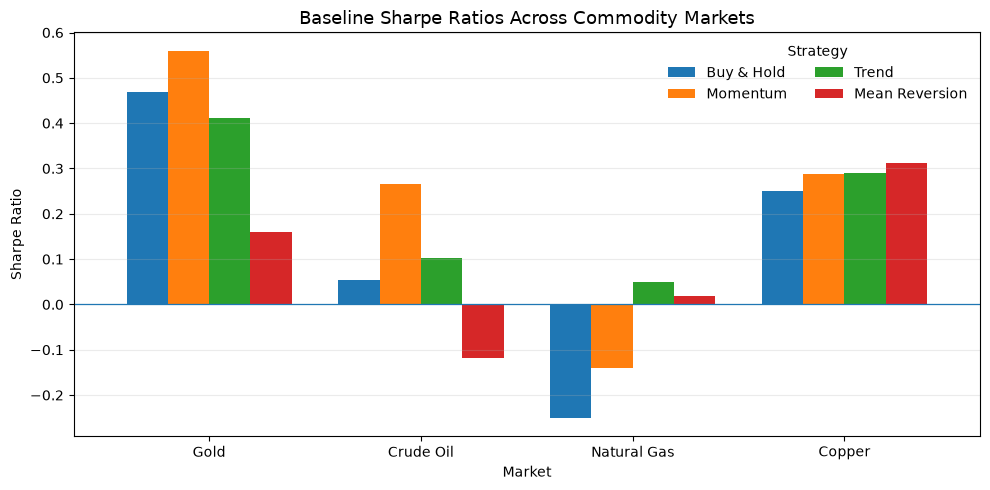

In [108]:
# Figure 3 gonna adjust for risk
sharpeTable = (
    baseline["Sharpe Ratio"]
    .unstack("Strategy")
    .loc[markets, ["Buy & Hold", "Momentum", "Trend", "Mean Reversion"]]
)

ax = sharpeTable.plot(
    kind="bar",
    figsize=(10, 5),
    width=0.78
)

ax.axhline(
    0,
    linewidth=0.9
)

ax.set_title(
    "Baseline Sharpe Ratios Across Commodity Markets",
    fontsize=13
)

ax.set_xlabel("Market")
ax.set_ylabel("Sharpe Ratio")

ax.set_xticklabels(
    ["Gold", "Crude Oil", "Natural Gas", "Copper"],
    rotation=0
)

ax.legend(
    title="Strategy",
    frameon=False,
    ncol=2
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "figures/figure_03_baseline_sharpe.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Transaction Costs

The baseline backtest assumes trading is free. Real strategies pay a cost whenevr the position changes.

We measure trading acivity using turnover, when 0 goes to 1 buy, when 1 goes to 0 you sell and no chnage means no trade:

$$
\text{Turnover}_t
=
|\text{Position}_t-\text{Position}_{t-1}|
$$

Lets assume cost per unit of turnover is $c$, net return then becomes:

$$
R_t^{net}
=
R_t^{gross}
-
c \times \text{Turnover}_t
$$

So I have decided to test 0 5 10 and 20 basis points or bp per position change.

$$
1\text{ bp} = 0.01\%
$$

Testing several just seems smart here lets us see whther strategy remains useful once trading is no longer assumed free.


In [109]:
#calc turnover once
# work out how much each strategy is actually trading

turnover = {}

for market in markets:

    held = heldPositions[market]

    moves = held.diff().abs()

    # begin with cash
    moves.iloc[0] = held.iloc[0].abs()

    turnover[market] = moves

In [110]:
# simplet table, over full sample

tradeActivity = pd.DataFrame({
    market: turnover[market].sum()
    for market in markets
}).T

tradeActivity.index.name = "Market"

tradeActivity

,Buy & Hold,Momentum,Trend,Mean Reversion
Market,,,,
GLD,1.0,94.0,22.0,154.0
USO,1.0,147.0,29.0,170.0
UNG,1.0,158.0,18.0,180.0
CPER,1.0,147.0,27.0,174.0


In [111]:
tradeActivity["Buy & Hold"]

Market
GLD     1.0
USO     1.0
UNG     1.0
CPER    1.0
Name: Buy & Hold, dtype: float64

In [112]:
# now to apply all 4 cost levels
# testing the same trading costs acoss every market and evry strat

costLevels = [0, 5, 10, 20]

costRows = []

for market in markets:

    gross = backtests[market]
    moves = turnover[market]

    for bp in costLevels:

        cost = bp / 10000
        net = gross - cost * moves

        for strategy in gross.columns:

            scores = scorecard(net[strategy])

            costRows.append({
                "Market": market,
                "Strategy": strategy,
                "Cost (bp)": bp,
                "Total Return": scores["Total Return"],
                "CAGR": scores["CAGR"],
                "Sharpe Ratio": scores["Sharpe Ratio"],
                "Maximum Drawdown": scores["Maximum Drawdown"]
            })

costResults = pd.DataFrame(costRows)

costResults.head()

,Market,Strategy,Cost (bp),Total Return,CAGR,Sharpe Ratio,Maximum Drawdown
0,GLD,Buy & Hold,0,1.410695,0.065496,0.468221,-0.407464
1,GLD,Momentum,0,1.457724,0.066981,0.559941,-0.259789
2,GLD,Trend,0,0.867784,0.046073,0.410549,-0.264713
3,GLD,Mean Reversion,0,0.155428,0.010471,0.160172,-0.214599
4,GLD,Buy & Hold,5,1.409491,0.065458,0.468002,-0.407464


In [113]:
# A compact view of how Sharpe changes as trading gets more expensive
costTable = costResults.pivot_table(
    index=["Market", "Strategy"],
    columns="Cost (bp)",
    values="Sharpe Ratio"
)

costTable.columns = [
    f"{bp} bp"
    for bp in costTable.columns
]

costTable.round(2)

0 bp  5 bp  10 bp  20 bp
Market Strategy                                
CPER   Buy & Hold      0.25  0.25   0.25   0.25
       Mean Reversion  0.31  0.29   0.26   0.21
       Momentum        0.29  0.26   0.23   0.17
       Trend           0.29  0.28   0.28   0.27
GLD    Buy & Hold      0.47  0.47   0.47   0.47
       Mean Reversion  0.16  0.10   0.04  -0.08
       Momentum        0.56  0.53   0.51   0.46
       Trend           0.41  0.40   0.40   0.39
UNG    Buy & Hold     -0.25 -0.25  -0.25  -0.25
       Mean Reversion  0.02 -0.00  -0.03  -0.07
       Momentum       -0.14 -0.16  -0.18  -0.21
       Trend           0.05  0.05   0.05   0.04
USO    Buy & Hold      0.05  0.05   0.05   0.05
       Mean Reversion -0.12 -0.14  -0.17  -0.21
       Momentum        0.27  0.24   0.22   0.18
       Trend           0.10  0.10   0.09   0.08

### Cost sensitivity

A strategy that only looks attractive when trading is assumed to be free is not convincing

The figure I aim to make below shows how each strategys Sharpe ratio changes as the assumed cost per position change rises from 0 to 20 bp.

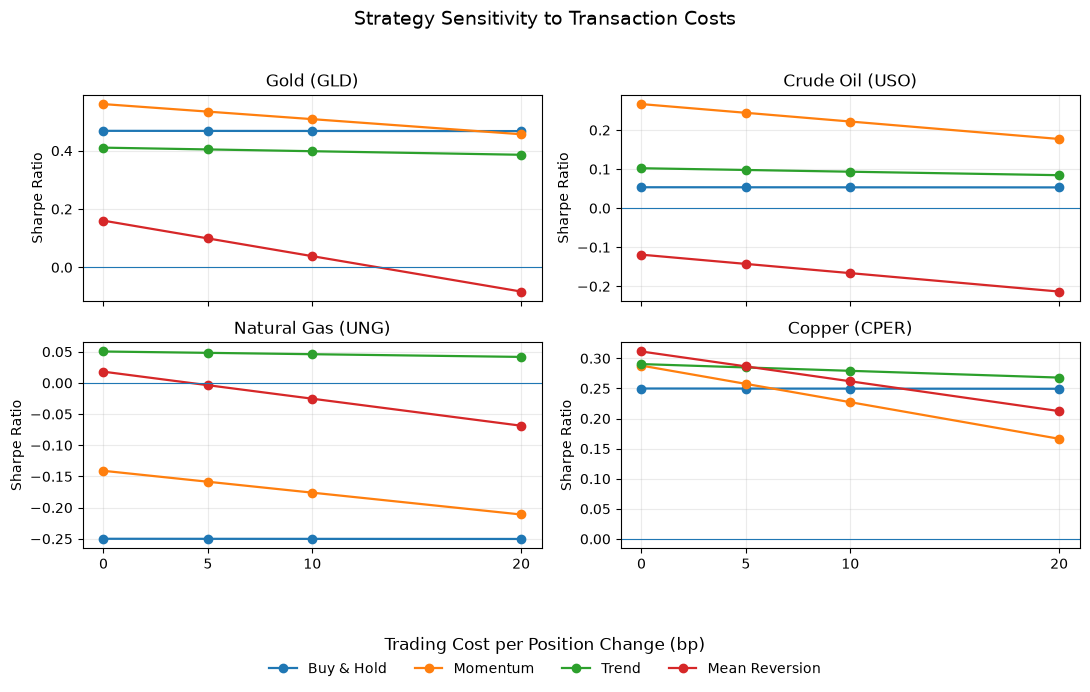

In [114]:
# Figure 4
fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 7),
    sharex=True
)

axes = axes.flatten()

strategyOrder = [
    "Buy & Hold",
    "Momentum",
    "Trend",
    "Mean Reversion"
]

for ax, market in zip(axes, markets):

    marketCosts = costResults[costResults["Market"] == market]

    for strategy in strategyOrder:

        line = marketCosts[
            marketCosts["Strategy"] == strategy
        ]

        ax.plot(
            line["Cost (bp)"],
            line["Sharpe Ratio"],
            marker="o",
            linewidth=1.6,
            label=strategy
        )

    ax.axhline(0, linewidth=0.8)
    ax.set_title(marketNames[market])
    ax.set_ylabel("Sharpe Ratio")
    ax.set_xticks(costLevels)
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01)
)

fig.suptitle(
    "Strategy Sensitivity to Transaction Costs",
    fontsize=14
)

fig.supxlabel(
    "Trading Cost per Position Change (bp)",
    y=0.06
)

fig.tight_layout(
    rect=[0, 0.11, 1, 0.96]
)

fig.savefig(
    "figures/figure_04_transaction_costs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Time Robustness

Now a strat can look convincing simply because it happened to suit one particular period of market history.

To test whther the results depend heavily on timing, we now need to split the sampel into 2 time periods:

- **Earlier period:** start of the backtest to 31 December 2019
- **Later period:** 1 January 2020 to the end of the sample

(This is your training and test period see notebook)



In [115]:
# SPLIT nto earlier and later
splitDate = "2020-01-01"

periods = {}

for market in markets:

    earlier = backtests[market].loc[: "2019-12-31"]
    later = backtests[market].loc[splitDate:]

    periods[market] = {
        "Earlier": earlier,
        "Later": later
    }

print("Earlier period:", periods["GLD"]["Earlier"].index[0].date(),
      "to", periods["GLD"]["Earlier"].index[-1].date())

print("Later period:  ", periods["GLD"]["Later"].index[0].date(),
      "to", periods["GLD"]["Later"].index[-1].date())

Earlier period: 2012-10-17 to 2019-12-31
Later period:   2020-01-02 to 2026-08-31


In [116]:
# now measure every strat in both time period:

timeRows = []

for market in markets:

    for period, data in periods[market].items():

        for strategy in data.columns:

            scores = scorecard(data[strategy])

            timeRows.append({
                "Market": market,
                "Period": period,
                "Strategy": strategy,
                "CAGR": scores["CAGR"],
                "Sharpe Ratio": scores["Sharpe Ratio"],
                "Maximum Drawdown": scores["Maximum Drawdown"]
            })

timeResults = pd.DataFrame(timeRows)

timeResults.head()

,Market,Period,Strategy,CAGR,Sharpe Ratio,Maximum Drawdown
0,GLD,Earlier,Buy & Hold,-0.023356,-0.091305,-0.407464
1,GLD,Earlier,Momentum,0.015532,0.218675,-0.160676
2,GLD,Earlier,Trend,-0.010343,-0.082095,-0.244670
3,GLD,Earlier,Mean Reversion,-0.010782,-0.067211,-0.214599
4,GLD,Later,Buy & Hold,0.170759,0.949296,-0.264045


In [117]:
# The clearest summary of how behaviour changes through time
timeTable = timeResults.pivot_table(
    index=["Market", "Strategy"],
    columns="Period",
    values="Sharpe Ratio"
)

timeTable = timeTable[["Earlier", "Later"]]

timeTable.round(2)

Period                 Earlier  Later
Market Strategy                      
CPER   Buy & Hold         0.02   0.60
       Mean Reversion     0.27   0.52
       Momentum          -0.13   0.55
       Trend             -0.05   0.49
GLD    Buy & Hold        -0.09   0.95
       Mean Reversion    -0.07   0.42
       Momentum           0.22   0.80
       Trend             -0.08   0.71
UNG    Buy & Hold        -0.41  -0.15
       Mean Reversion    -0.09   0.09
       Momentum          -0.15  -0.14
       Trend             -0.14   0.21
USO    Buy & Hold        -0.28   0.32
       Mean Reversion    -0.45   0.12
       Momentum          -0.20   0.56
       Trend             -0.37   0.40

### Earlier vs later

The sharpe ratio below shows how the same fixed strat rules behaved in the two different parts of the sample

LArge changes between period = performance depends strongly on the market environment rather than being constant through time.

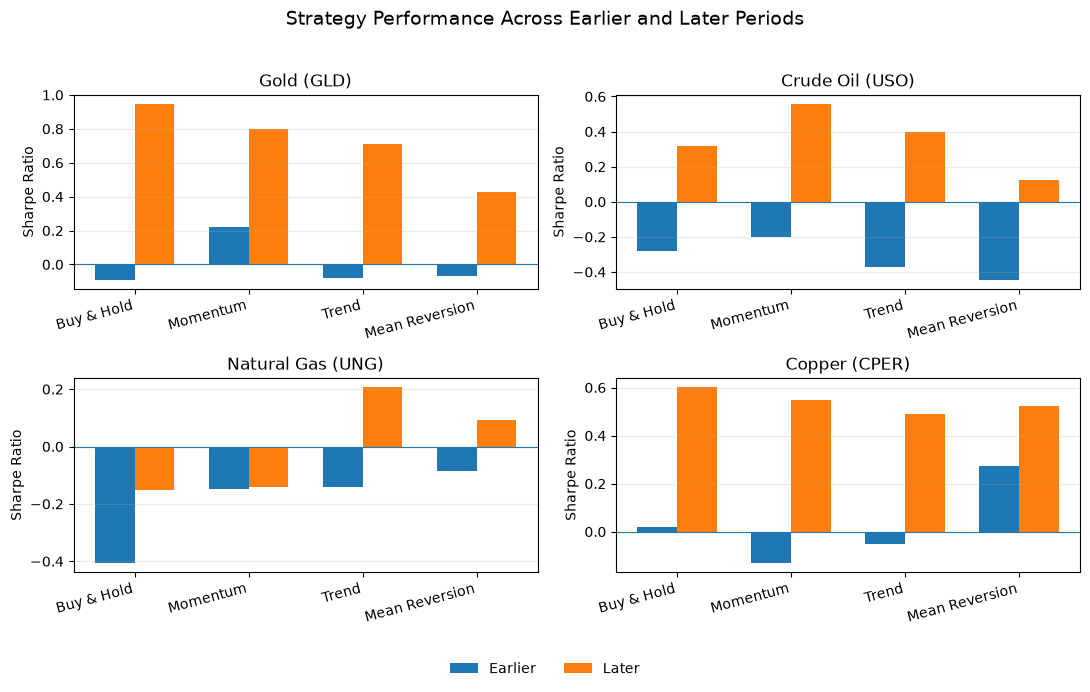

In [118]:
# Figure 5 — compare the same strategies across two time periods
fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 7),
    sharey=False
)

axes = axes.flatten()

strategyOrder = [
    "Buy & Hold",
    "Momentum",
    "Trend",
    "Mean Reversion"
]

x = np.arange(len(strategyOrder))
width = 0.35

for ax, market in zip(axes, markets):

    earlier = (
        timeTable
        .loc[market]
        .loc[strategyOrder, "Earlier"]
    )

    later = (
        timeTable
        .loc[market]
        .loc[strategyOrder, "Later"]
    )

    ax.bar(
        x - width / 2,
        earlier,
        width,
        label="Earlier"
    )

    ax.bar(
        x + width / 2,
        later,
        width,
        label="Later"
    )

    ax.axhline(0, linewidth=0.8)

    ax.set_title(marketNames[market])
    ax.set_ylabel("Sharpe Ratio")

    ax.set_xticks(x)
    ax.set_xticklabels(
        strategyOrder,
        rotation=15,
        ha="right"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01)
)

fig.suptitle(
    "Strategy Performance Across Earlier and Later Periods",
    fontsize=14
)

fig.tight_layout(
    rect=[0, 0.08, 1, 0.96]
)

fig.savefig(
    "figures/figure_05_time_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

PErformance changes substantilly between two period.

Gold and crude oil strats generally perform much better afte 2020, while natrual gas remains diffciult in both periods. Copper also improves noticeably in the later sample

This suggests that strategy performance is **time-dependent**, so the full-sample results should not be treated as permanent characteristics of the strategies.

## 8. Parameters

A trading idea is less convincing if its results depend on exactly one paramter choice.

SO in that case we are going to repeat the experiment using a small set of predefined alternative settings still around the baseline rules.

### Momentum

$$
63,\ 126,\ 252 \text{ trading days}
$$

### Trend Following

$$
20/100,\quad 50/200,\quad 100/200
$$

where each pair represents the fast and slow moving-average windows.

### Mean Reversion

The 20-day z-score window and exit level of 0 are kept fixed, while the entry threshold is tested at:

$$
-1.0,\quad -1.5,\quad -2.0
$$

I will say the purpose isnt to optimise the strategies.

We are just testing whether the broad results survuve reasonable changes to the assumptions.

In [121]:
# little helper function, score one strat setting over the same common sample
sensitivityStart = prices.index[253]

def testSetting(price, position):

    marketReturn = price.pct_change()

    # Yesterday's decision controls today's return
    r = position.shift(1) * marketReturn

    # Fixed comparison period for every setting
    r = r.loc[sensitivityStart:].dropna()

    return scorecard(r)["Sharpe Ratio"]

## fix this need to be same dates

In [ ]:
# firstly momentum roughly 3 6 12 months

momentumSettings = [63, 126, 252]

momentumTest = []

for market in markets:

    price = prices[market]

    for days in momentumSettings:

        signal = price.pct_change(days)

        position = pd.Series(np.nan, index=price.index)
        ready = signal.notna()

        position.loc[ready] = (
            signal.loc[ready] > 0
        ).astype(float)

        momentumTest.append({
            "Market": market,
            "Setting": f"{days} days",
            "Sharpe Ratio": testSetting(price, position)
        })

momentumTest = pd.DataFrame(momentumTest)

momentumTest

## now apples to apples get rid of the pears

,Market,Setting,Sharpe Ratio
0,GLD,63 days,0.550565
1,GLD,126 days,0.597184
2,GLD,252 days,0.487058
3,USO,63 days,0.266824
4,USO,126 days,0.254971
5,USO,252 days,0.224362
6,UNG,63 days,-0.283796
7,UNG,126 days,-0.097716
8,UNG,252 days,-0.150831
9,CPER,63 days,0.046720


In [123]:
# now for trend using same

trendSettings = [
    (20, 100),
    (50, 200),
    (100, 200)
]

trendTest = []

for market in markets:

    price = prices[market]

    for fast, slow in trendSettings:

        fastMA = price.rolling(fast).mean()
        slowMA = price.rolling(slow).mean()

        position = pd.Series(np.nan, index=price.index)
        ready = slowMA.notna()

        position.loc[ready] = (
            fastMA.loc[ready] > slowMA.loc[ready]
        ).astype(float)

        trendTest.append({
            "Market": market,
            "Setting": f"{fast}/{slow}",
            "Sharpe Ratio": testSetting(price, position)
        })

trendTest = pd.DataFrame(trendTest)

trendTest

,Market,Setting,Sharpe Ratio
0,GLD,20/100,0.565719
1,GLD,50/200,0.445894
2,GLD,100/200,0.431380
3,USO,20/100,0.115648
4,USO,50/200,0.103090
5,USO,100/200,0.121140
6,UNG,20/100,-0.269737
7,UNG,50/200,0.094167
8,UNG,100/200,-0.081530
9,CPER,20/100,0.042626


In [ ]:
# finally mean reversion change the entry threshold
meanSettings = [-1.0, -1.5, -2.0]

meanTest = []

for market in markets:

    price = prices[market]

    average = price.rolling(meanDays).mean()
    spread = price.rolling(meanDays).std()
    zScore = (price - average) / spread

    for entry in meanSettings:

        position = pd.Series(np.nan, index=price.index)
        holding = 0

        for date in zScore.dropna().index:

            if zScore.loc[date] <= entry:
                holding = 1

            elif zScore.loc[date] >= exitZ:
                holding = 0

            position.loc[date] = holding

        meanTest.append({
            "Market": market,
            "Setting": f"z ≤ {entry}",
            "Sharpe Ratio": testSetting(price, position)
        })

meanTest = pd.DataFrame(meanTest)

meanTest



#### now we have comleter parameter set 

,Market,Setting,Sharpe Ratio
0,GLD,z ≤ -1.0,0.241254
1,GLD,z ≤ -1.5,0.174945
2,GLD,z ≤ -2.0,0.284808
3,USO,z ≤ -1.0,-0.156511
4,USO,z ≤ -1.5,-0.119065
5,USO,z ≤ -2.0,-0.170576
6,UNG,z ≤ -1.0,-0.136135
7,UNG,z ≤ -1.5,0.028162
8,UNG,z ≤ -2.0,0.016388
9,CPER,z ≤ -1.0,0.265720


In [125]:
# now to combine all 3 into a neat and tidy dataset

momentumTest["Strategy"] = "Momentum"
trendTest["Strategy"] = "Trend"
meanTest["Strategy"] = "Mean Reversion"

parameterResults = pd.concat(
    [momentumTest, trendTest, meanTest],
    ignore_index=True
)

parameterResults = parameterResults[
    ["Strategy", "Market", "Setting", "Sharpe Ratio"]
]

parameterResults.head()

,Strategy,Market,Setting,Sharpe Ratio
0,Momentum,GLD,63 days,0.550565
1,Momentum,GLD,126 days,0.597184
2,Momentum,GLD,252 days,0.487058
3,Momentum,USO,63 days,0.266824
4,Momentum,USO,126 days,0.254971


In [126]:
#comapct table for notebook readbale

parameterTable = parameterResults.pivot_table(
    index=["Strategy", "Setting"],
    columns="Market",
    values="Sharpe Ratio"
)

parameterTable = parameterTable[markets]

parameterTable.round(2)

Market                    GLD   USO   UNG  CPER
Strategy       Setting                         
Mean Reversion z ≤ -1.0  0.24 -0.16 -0.14  0.27
               z ≤ -1.5  0.17 -0.12  0.03  0.30
               z ≤ -2.0  0.28 -0.17  0.02  0.29
Momentum       126 days  0.60  0.25 -0.10  0.29
               252 days  0.49  0.22 -0.15  0.38
               63 days   0.55  0.27 -0.28  0.05
Trend          100/200   0.43  0.12 -0.08  0.10
               20/100    0.57  0.12 -0.27  0.04
               50/200    0.45  0.10  0.09  0.30

### Parameter sensitivity

BAseline setting is the middle point for each test.

If nearby parameter choices produce broadly similar results, the trading idea is less dependent on one exact numebr the parameter were testing.

Large swings however indicate greater paramter sens.

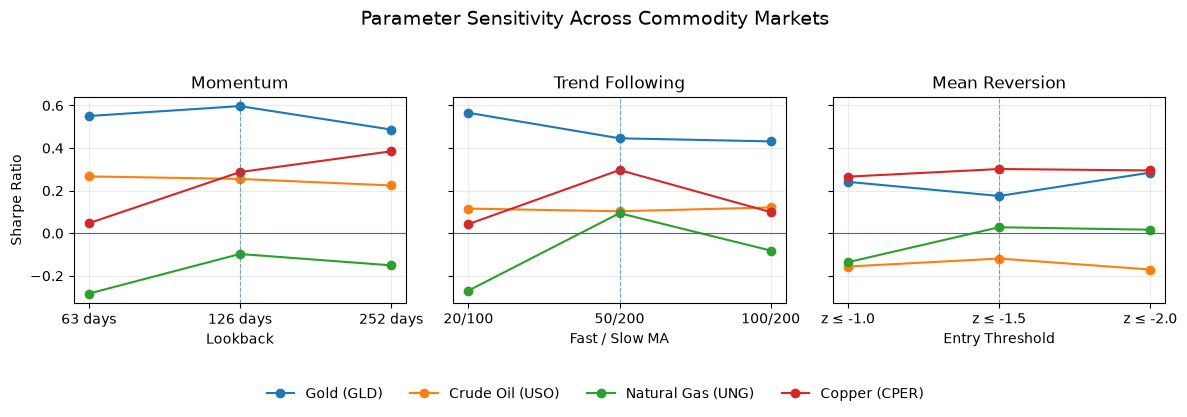

In [127]:
#figure 6 how sensitive each strat is to its settings

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4),
    sharey=True
)

tests = [
    (
        axes[0],
        momentumTest,
        ["63 days", "126 days", "252 days"],
        "Momentum",
        "Lookback"
    ),
    (
        axes[1],
        trendTest,
        ["20/100", "50/200", "100/200"],
        "Trend Following",
        "Fast / Slow MA"
    ),
    (
        axes[2],
        meanTest,
        ["z ≤ -1.0", "z ≤ -1.5", "z ≤ -2.0"],
        "Mean Reversion",
        "Entry Threshold"
    )
]

x = np.arange(3)

for ax, data, settings, title, xLabel in tests:

    for market in markets:

        line = (
            data[data["Market"] == market]
            .set_index("Setting")
            .loc[settings]
        )

        ax.plot(
            x,
            line["Sharpe Ratio"],
            marker="o",
            linewidth=1.5,
            label=marketNames[market]
        )

    # Middle setting is our original baseline rule
    ax.axvline(
        1,
        linewidth=0.8,
        linestyle="--",
        alpha=0.6
    )

    ax.axhline(0, linewidth=0.8)

    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_xticks(x)
    ax.set_xticklabels(settings)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Sharpe Ratio")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.03)
)

fig.suptitle(
    "Parameter Sensitivity Across Commodity Markets",
    fontsize=14
)

fig.tight_layout(
    rect=[0, 0.10, 1, 0.94]
)

fig.savefig(
    "figures/figure_06_parameter_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Parameter robustness

The results show differnt lebels of sensitibity across markets and strats.

Momentum relatively stable in gold and crude oil, but more sensitive in copper. Trend is noticeably parameter dependent in natural gas and copper. Mean reversion is comparatively stabel in copperbut remains weak in crude oil across all three thresholfs.



## 9. Cross-Market findings

Baseline and robustness tests can now be considered together.

Rather than asking which strat produced the highest historical return, we now ask ourselves 4 questions:

1) Did the strategy improve risk-adjusted performance relative to Buy & Hold?
2) Did the result survive reasonable transaction costs?
3) Did similar behaviour appear in both time periods?
4) Was the result reasonable stable when the strategy setting changed?

This allows us to distinguish a strong-looking backtest from a result that is genuinely more robust.



In [128]:
# putting togtehrt the numbers we already have

# bring main robustness evidence into one table

summaryRows = []

for market in markets:

    for strategy in [
        "Buy & Hold",
        "Momentum",
        "Trend",
        "Mean Reversion"
    ]:

        baselineSharpe = baseline.loc[
            (market, strategy),
            "Sharpe Ratio"
        ]

        costSharpe = costResults[
            (costResults["Market"] == market) &
            (costResults["Strategy"] == strategy) &
            (costResults["Cost (bp)"] == 20)
        ]["Sharpe Ratio"].iloc[0]

        earlierSharpe = timeTable.loc[
            (market, strategy),
            "Earlier"
        ]

        laterSharpe = timeTable.loc[
            (market, strategy),
            "Later"
        ]

        summaryRows.append({
            "Market": market,
            "Strategy": strategy,
            "Baseline Sharpe": baselineSharpe,
            "Sharpe at 20 bp": costSharpe,
            "Earlier Sharpe": earlierSharpe,
            "Later Sharpe": laterSharpe
        })

summary = pd.DataFrame(summaryRows).set_index(
    ["Market", "Strategy"]
)

summary.round(2)

Baseline Sharpe  Sharpe at 20 bp  Earlier Sharpe  \
Market Strategy                                                           
GLD    Buy & Hold                 0.47             0.47           -0.09   
       Momentum                   0.56             0.46            0.22   
       Trend                      0.41             0.39           -0.08   
       Mean Reversion             0.16            -0.08           -0.07   
USO    Buy & Hold                 0.05             0.05           -0.28   
       Momentum                   0.27             0.18           -0.20   
       Trend                      0.10             0.08           -0.37   
       Mean Reversion            -0.12            -0.21           -0.45   
UNG    Buy & Hold                -0.25            -0.25           -0.41   
       Momentum                  -0.14            -0.21           -0.15   
       Trend                      0.05             0.04           -0.14   
       Mean Reversion             0.02            -0.07           -0.09   
CPER   Buy & Hold                 0.25             0.25            0.02   
       Momentum                   0.29             0.17           -0.13   
       Trend                      0.29             0.27           -0.05   
       Mean Reversion             0.31             0.21            0.27   

                       Later Sharpe  
Market Strategy                      
GLD    Buy & Hold              0.95  
       Momentum                0.80  
       Trend                   0.71  
       Mean Reversion          0.42  
USO    Buy & Hold              0.32  
       Momentum                0.56  
       Trend                   0.40  
       Mean Reversion          0.12  
UNG    Buy & Hold             -0.15  
       Momentum               -0.14  
       Trend                   0.21  
       Mean Reversion          0.09  
CPER   Buy & Hold              0.60  
       Momentum                0.55  
       Trend                   0.49  
       Mean Reversion          0.52

### What is the market telling us

**Gold**

Momentum produces the strongest baseline risk-adjusted performance. Its Sharpe ratio remains positive under higher transaction costs and is positive in both time periods. Nearby momentum lookbacks also produce broadly similar results, making gold the clearest example of relatively robust momentum behaviour in the study.

**Crude Oil**

Momentum also performs best at the baseline level and remains positive after transaction costs. However, its earlier-period Sharpe ratio is negative and its later-period Sharpe is much stronger. The result therefore appears more dependent on the market environment than the gold result.

**Natural Gas**

No strategy produces consistently strong performance. Buy & Hold performs particularly poorly, while the systematic rules reduce some of the damage. Trend following is the least weak of the strategies overall, but its performance remains modest and parameter-sensitive.

**Copper**

The strategies are much closer together than in gold or oil. Mean reversion produces the strongest baseline Sharpe ratio and remains positive under transaction costs and in both time periods. Its nearby entry thresholds also produce relatively similar results, suggesting greater stability than the other copper strategies.

### Answer to research question

The result do not support the idea that one simple systematic strat works consistenyl across all commodity markets. Instead, performance heavily depends on both the commodity and the market enviornemnt.

Momentum provides the clearest eveidence of improved risk-adjusted performance in gold. It produces a higher basiline sharpe ratio than buy and hold, remains potitive after realtively high transaction costs, performs portively in both time periods, and remains reasonbably strong across nearby lookback windows. Momentum also improves the crude-oil results, although its performance is much stronger after 2020 than before it, making the oil result less stable through time.

The other markets tell a different story. **Natural gas** is difficult for every approach: systematic strategies reduce some of the extreme losses seen under Buy & Hold, but none produces consistently strong risk-adjusted performance. **Copper** shows the strongest evidence for mean reversion, which remains positive after transaction costs, performs positively in both periods and is relatively stable across nearby entry thresholds.

Overall, simple systematic rules can improve the risk-return profile of some commodity exposures, but the effect is **market-specific rather than universal**. Transaction costs, time period and parameter choice materially affect the conclusions, so strong historical performance alone is not sufficient evidence of a robust trading strategy.

## 10. COnclusions and limitations

### Conclusion

This project tested Buy & Hold, momentum, trend following and mean reversion across gold, crude oil, natural gas and copper exposures from 2012 to 2026.

The results show that systematic trading rules can alter both returns and risk substantially, but their effectiveness varies across markets.

The strongest evidence in this study is:

- relatively robust momentum behaviour in gold
- weaker but still notable momentum behaviour in crude oil
- limited success across natural gas
- comparatively robust mean-reversion behaviour in copper

More broadly, the study shows why trading strategies should be judged using more than historical return alone. Drawdowns, risk-adjusted performance, transaction costs, changing market environments and parameter sensitivity all materially affect how convincing a backtest is.

### Limitations

I have several limitations to keep in mind:

- GLD, USO, UNG and CPER are exchange-traded **proxies** for commodity exposure rather than physical spot commodities.
- USO, UNG and CPER can be affected by the structure and rolling of the futures contracts they hold.
- The backtest assumes trades can be executed at the modelled daily prices and does not include bid-ask spreads, market impact or taxes beyond the simplified transaction-cost test.
- The strategies are intentionally simple and use long-or-cash positions only.
- The chronological time split is a robustness check rather than a completely untouched live out-of-sample experiment.
- The Yahoo Finance CPER series contains unusual historical observations, which may influence some copper statistics.
- Historical robustness does not imply that the same relationships will persist in the future.

The limtations do not invalidate the experiment but they define what conclusions can be reasonably drawn from it.

### Export final data

Analasysi complete

In [129]:
# Save the finished research outputs in one place

# Clean market data
prices.to_csv("data/commodity_prices.csv")
returns.to_csv("data/daily_returns.csv")

# Main research results
baseline.to_csv("results/baseline_results.csv")
tradeActivity.to_csv("results/trading_activity.csv")

costResults.to_csv(
    "results/transaction_cost_results.csv",
    index=False
)

timeResults.to_csv(
    "results/time_robustness_results.csv",
    index=False
)

parameterResults.to_csv(
    "results/parameter_robustness_results.csv",
    index=False
)

summary.to_csv("results/final_summary.csv")

print("Project outputs saved.")

Project outputs saved.
